# 🖐️ Irish Sign Language (ISL) Alphabet Recognition with MobileNetV2

## Introduction

This notebook demonstrates the complete workflow for building a **deep learning model** to recognize static Irish Sign Language (ISL) alphabet signs from images.  
The final trained model will be lightweight and optimized for **real-time inference**, making it suitable for integration into a **FastAPI web service** and potential deployment on edge devices.

### 📂 Dataset
We use the **ISL-HS (Irish Sign Language Handshape) dataset**, which contains high-quality images of 22 static ISL letters (A–Z, excluding **J, X, Z** which are dynamic gestures).  
The dataset is located at:

```
data/processed/ISL-HS/static/
```

Each letter class contains **2000+ training images** captured under different lighting conditions and backgrounds.

### 🎯 Project Goals
1. **Data exploration & preprocessing** with augmentation to improve generalization.
2. **Model building** using MobileNetV2 for a balance of accuracy and speed.
3. **Training & validation** with reproducible metrics.
4. **Model evaluation** including accuracy, confusion matrix, and class-wise performance.
5. **Model saving/export** for integration into a real-time ISL recognition API.

### 📦 Technical Stack
- **TensorFlow / Keras**: Deep learning framework for model creation and training.
- **OpenCV**: Image processing and potential integration with MediaPipe.
- **Matplotlib / Seaborn**: Data visualization for EDA and results.
- **Scikit-learn**: Evaluation metrics and confusion matrix.
- **MediaPipe** (optional): Hand landmark detection (possible future use).

---


## 1. Environment Setup and Dependency Installation

Before we start working with the dataset or building our ISL recognition model, we need to set up a **self-contained and reproducible environment**.  
This step ensures that anyone running this notebook — on any machine — can install the required dependencies and reproduce the same results.

### 🔹 What We’ll Do
1. **Install dependencies**:
   - **TensorFlow/Keras** — deep learning framework for building and training the MobileNetV2 model.
   - **OpenCV** — image loading, resizing, and preprocessing.
   - **MediaPipe** — optional hand landmark detection (possible future use).
   - **Matplotlib/Seaborn** — visualizing the dataset and results.
   - **Scikit-learn** — evaluation metrics and confusion matrix.
   - **Pandas, NumPy, tqdm** — data handling and utilities.
2. **Platform-aware TensorFlow installation**:
   - On Apple Silicon (M1/M2/M3), we install `tensorflow-macos` and `tensorflow-metal` for GPU acceleration.
   - On other platforms, we install the standard `tensorflow` package.
3. **Set seeds for reproducibility**:
   - Fix random seeds for Python, NumPy, and TensorFlow so results are consistent between runs.
4. **Check available hardware**:
   - Detect CPU, GPU, or Apple Metal backend to optimize performance.
5. **Create project directories**:
   - `outputs/models/` — save trained models.
   - `outputs/plots/` — store training/evaluation visualizations.
   - `outputs/history/` — store training history JSON or CSV files.
6. **Sanity check the dataset**:
   - Confirm that `data/processed/ISL-HS/static/` exists.
   - List all detected classes (letters) and count images per class.

### ✅ Expected Output
- Successful `pip install` without major errors.
- Library version printout (TensorFlow, NumPy, OpenCV, etc.).
- Device check showing GPU/MPS if available.
- Confirmation that dataset directory exists and classes are detected with correct image counts.
---

In [3]:
# Step 1 — Environment setup & dependency installation
# Updated to resolve dataset path relative to project root

import sys, subprocess, platform, os, random, pathlib

def pip_install(pkgs):
    if isinstance(pkgs, str):
        pkgs = [pkgs]
    cmd = [sys.executable, "-m", "pip", "install", "-q"] + pkgs
    print(f"↳ pip {' '.join(pkgs)}")
    subprocess.check_call(cmd)

# Platform-aware TensorFlow
system = platform.system()
machine = platform.machine().lower()
TF_RANGE = ">=2.15,<2.18"

if system == "Darwin" and any(k in machine for k in ["arm", "apple", "aarch64"]):
    tf_pkgs = [f"tensorflow-macos{TF_RANGE}", f"tensorflow-metal"]
else:
    tf_pkgs = [f"tensorflow{TF_RANGE}"]

base_pkgs = [
    "numpy>=1.23,<2.0",
    "opencv-python>=4.8",
    "mediapipe>=0.10.0",
    "matplotlib>=3.8",
    "seaborn>=0.13",
    "scikit-learn>=1.3",
    "pandas>=2.0",
    "tqdm>=4.66"
]

try:
    pip_install(tf_pkgs + base_pkgs)
except subprocess.CalledProcessError as e:
    print("⚠️ Pip installation encountered an error.")
    print(e)

# Imports & versions
import numpy as np
import tensorflow as tf
import cv2, mediapipe as mp, matplotlib, seaborn, sklearn, pandas as pd

print("\n✅ Versions")
print(f"  Python         : {sys.version.split()[0]}")
print(f"  TensorFlow     : {tf.__version__}")
print(f"  NumPy          : {np.__version__}")
print(f"  OpenCV         : {cv2.__version__}")
print(f"  MediaPipe      : {mp.__version__}")
print(f"  Matplotlib     : {matplotlib.__version__}")
print(f"  Seaborn        : {seaborn.__version__}")
print(f"  scikit-learn   : {sklearn.__version__}")
print(f"  Pandas         : {pd.__version__}")

# Reproducibility
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# Accelerator check
print("\n✅ Accelerator Check")
physical_gpus = tf.config.list_physical_devices('GPU')
try:
    for gpu in physical_gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
except Exception:
    pass

if physical_gpus:
    print(f"  GPUs available : {len(physical_gpus)} -> {physical_gpus}")
else:
    print("  GPUs available : 0 (CPU or Apple Metal backend)")

from tensorflow.python.client import device_lib
devices = device_lib.list_local_devices()
device_types = sorted(set(d.device_type for d in devices))
print(f"  TF devices     : {device_types}")

if physical_gpus:
    try:
        from tensorflow.keras import mixed_precision
        mixed_precision.set_global_policy("mixed_float16")
        print("  Mixed precision: enabled (mixed_float16)")
    except Exception as e:
        print(f"  Mixed precision: not enabled -> {e}")

# Project directories — Option A: set root to parent of notebooks/
PROJECT_ROOT = pathlib.Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR     = PROJECT_ROOT / "data" / "raw" / "Frames"
OUTPUT_DIR   = PROJECT_ROOT / "outputs"
(MODELS_DIR := OUTPUT_DIR / "models").mkdir(parents=True, exist_ok=True)
(PLOTS_DIR  := OUTPUT_DIR / "plots").mkdir(parents=True, exist_ok=True)
(HIST_DIR   := OUTPUT_DIR / "history").mkdir(parents=True, exist_ok=True)

print("\n✅ Project Paths")
print(f"  Project root   : {PROJECT_ROOT}")
print(f"  Data dir       : {DATA_DIR} {'(exists)' if DATA_DIR.exists() else '(NOT FOUND ⚠️)'}")
print(f"  Models dir     : {MODELS_DIR}")
print(f"  Plots dir      : {PLOTS_DIR}")
print(f"  History dir    : {HIST_DIR}")

# Dataset sanity check
def is_image_file(p: pathlib.Path):
    return p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp"}

class_names = []
per_class_counts = {}

if DATA_DIR.exists():
    for d in sorted(DATA_DIR.iterdir()):
        if d.is_dir():
            class_names.append(d.name)
            count = sum(1 for p in d.iterdir() if p.is_file() and is_image_file(p))
            per_class_counts[d.name] = count

    print("\n✅ Dataset Summary")
    print(f"  Classes found  : {len(class_names)}")
    print(f"  Class names    : {', '.join(class_names) if class_names else '(none)'}")
    if per_class_counts:
        preview_items = list(per_class_counts.items())[:8]
        print("  Sample counts  : " + " | ".join([f"{k}:{v}" for k, v in preview_items]) + (" | ..." if len(per_class_counts) > 8 else ""))
        total_images = sum(per_class_counts.values())
        print(f"  Total images   : {total_images}")
        empties = [k for k, v in per_class_counts.items() if v == 0]
        if empties:
            print(f"  ⚠️ Empty classes: {', '.join(empties)}")
else:
    print("\n❌ Dataset directory not found. Please verify the path:")
    print(f"   Expected at: {DATA_DIR}")

print("\n✅ Step 1 complete.")


↳ pip tensorflow-macos>=2.15,<2.18 tensorflow-metal numpy>=1.23,<2.0 opencv-python>=4.8 mediapipe>=0.10.0 matplotlib>=3.8 seaborn>=0.13 scikit-learn>=1.3 pandas>=2.0 tqdm>=4.66

✅ Versions
  Python         : 3.12.5
  TensorFlow     : 2.16.2
  NumPy          : 1.26.4
  OpenCV         : 4.11.0
  MediaPipe      : 0.10.21
  Matplotlib     : 3.10.3
  Seaborn        : 0.13.2
  scikit-learn   : 1.7.0
  Pandas         : 2.3.0

✅ Accelerator Check
  GPUs available : 1 -> [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
  TF devices     : ['CPU', 'GPU']
  Mixed precision: enabled (mixed_float16)

✅ Project Paths
  Project root   : /Users/rharris/college/PRO/deafInclusionTool/comharthai
  Data dir       : /Users/rharris/college/PRO/deafInclusionTool/comharthai/data/raw/Frames (exists)
  Models dir     : /Users/rharris/college/PRO/deafInclusionTool/comharthai/outputs/models
  Plots dir      : /Users/rharris/college/PRO/deafInclusionTool/comharthai/outputs/plots
  History dir    :

## 2. Data Exploration & Visualization

Before we preprocess the dataset for training, we need to understand **what’s in it** and ensure it’s suitable for a static ISL alphabet recognition model.

### 🎯 Goals of This Step
1. **Parse and validate labels**:
   - Extract the **letter** from each filename (format: `PersonN-Letter-Shot-Frame.jpg`).
   - Identify and **exclude** dynamic gesture letters (**J, X, Z**) from static model training.
2. **Class distribution**:
   - Count how many images we have for each static letter.
   - Check for any class imbalance that may require augmentation later.
3. **Visual audit**:
   - Display random sample images to verify correct labeling and general quality.
4. **Image size & aspect ratio check**:
   - Gather statistics on width, height, and aspect ratio.
   - Use this to justify our final image size for model input (e.g., 224×224 for MobileNetV2).
5. **Corrupt file check**:
   - Attempt to open a sample of images to catch any broken/corrupt files early.

### 📌 Why This Matters
- **Clean labels**: Mislabelled or dynamic gestures in the static dataset will reduce model accuracy.
- **Balanced classes**: If some letters have far fewer images, the model may overfit to more common ones.
- **Resolution choice**: MobileNetV2 works with fixed-size inputs — knowing the dataset’s image sizes helps avoid unnecessary distortion.
- **Quality control**: Visual checks help us confirm that extracted frames match the intended gestures.

---

Total static frames: 52688
Static letters: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'Y']
Persons: [1, 2, 3, 4, 5, 6]


/var/folders/kr/mgh360cd037129slwvp6j4200000gp/T/ipykernel_13628/2208688782.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=counts_df, x="letter", y="count", palette="viridis")


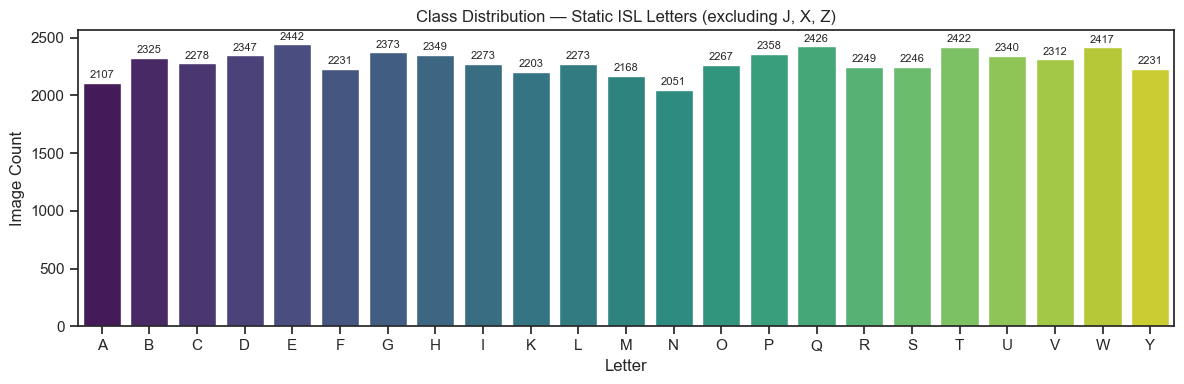

✅ No corrupt files found in sample of 200.

Image size summary (sample):
  Width  → min 640, p10 640, median 640, p90 640, max 640
  Height → min 480, p10 480, median 480, p90 480, max 480
  Aspect → min 1.33, p10 1.33, median 1.33, p90 1.33, max 1.33


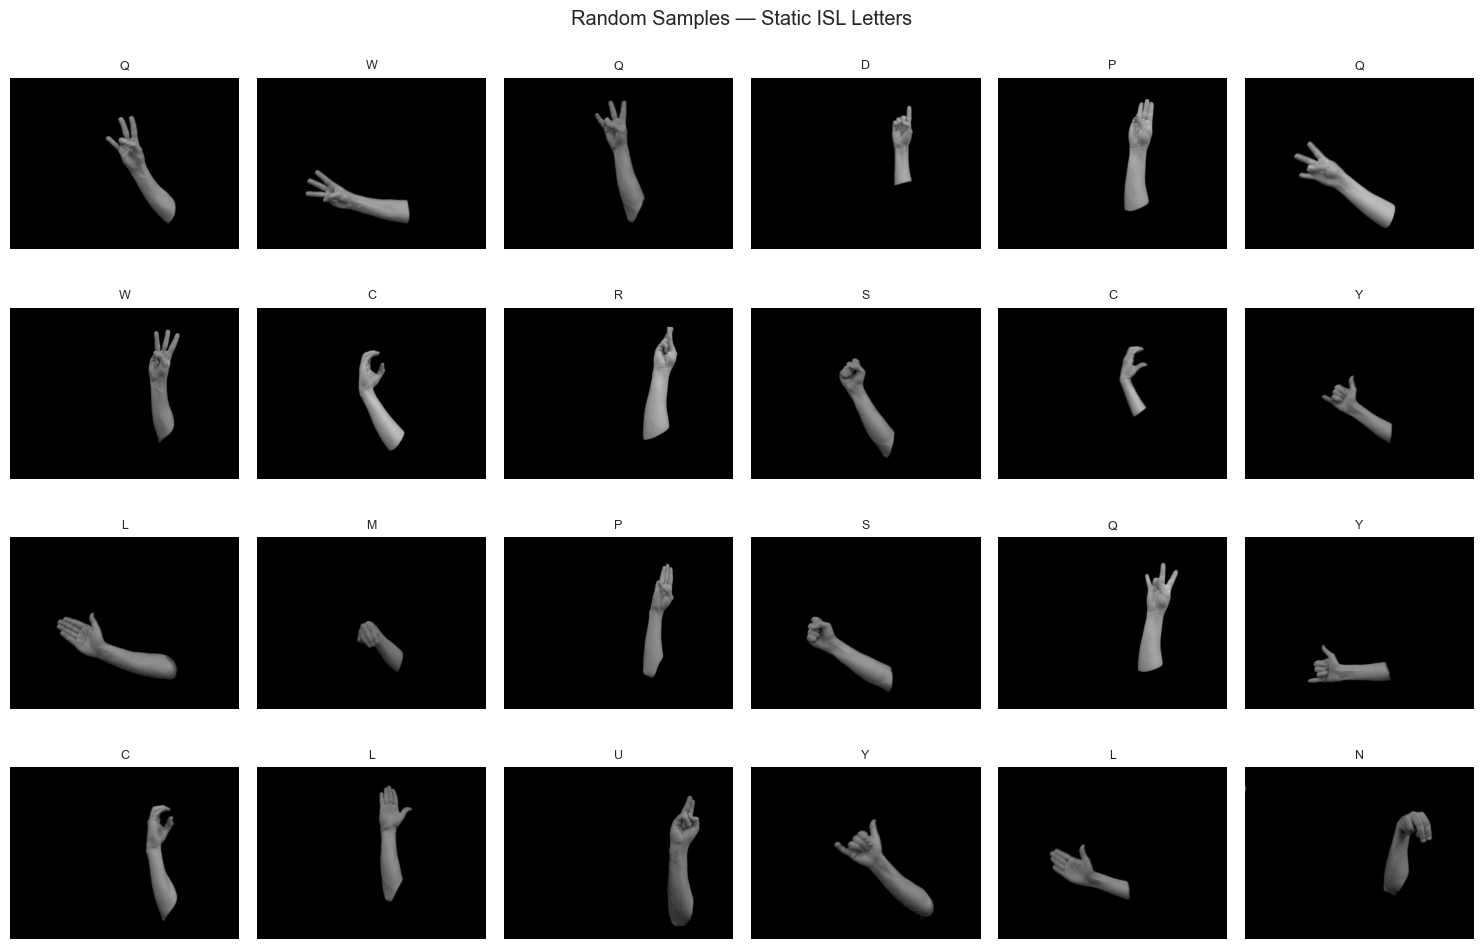

In [4]:
# Step 2 — Data exploration & visualization (static ISL letters only)

import re, math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from collections import Counter

sns.set_theme(context="notebook", style="ticks")

# Dataset path from Step 1
FRAMES_DIR = DATA_DIR
assert FRAMES_DIR.exists(), f"Dataset folder not found: {FRAMES_DIR}"

# Dynamic letters to exclude
DYNAMIC_LETTERS = {"J", "X", "Z"}

# Regex: PersonN-Letter-Shot-Frame.jpg
pat = re.compile(
    r"^Person(?P<person>\d+)-(?P<letter>[A-Za-z])-(?P<shot>\d+)-(?P<frame>\d+)\.(jpg|jpeg|png)$",
    re.IGNORECASE
)

records = []
for person_dir in sorted(FRAMES_DIR.iterdir()):
    if not person_dir.is_dir():
        continue
    for p in person_dir.iterdir():
        if not p.is_file():
            continue
        m = pat.match(p.name)
        if not m:
            continue
        letter = m.group("letter").upper()
        if letter in DYNAMIC_LETTERS:
            continue  # skip dynamic gestures
        records.append({
            "path": p,
            "person": int(m.group("person")),
            "letter": letter,
            "shot": int(m.group("shot")),
            "frame": int(m.group("frame"))
        })

df = pd.DataFrame(records)
print(f"Total static frames: {len(df)}")
print(f"Static letters: {sorted(df['letter'].unique().tolist())}")
print(f"Persons: {sorted(df['person'].unique().tolist())}")

# --- Counts per letter ---
counts = df["letter"].value_counts().sort_index()
counts_df = counts.reset_index()
counts_df.columns = ["letter", "count"]

plt.figure(figsize=(12, 4))
ax = sns.barplot(data=counts_df, x="letter", y="count", palette="viridis")
plt.title("Class Distribution — Static ISL Letters (excluding J, X, Z)")
plt.xlabel("Letter")
plt.ylabel("Image Count")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", label_type="edge", fontsize=8, padding=2)
plt.tight_layout()
plt.show()

# --- Corrupt file check (sample up to 200) ---
def is_corrupt(path):
    try:
        data = np.fromfile(str(path), dtype=np.uint8)
        if data.size == 0:
            return True
        img = cv2.imdecode(data, cv2.IMREAD_COLOR)
        return img is None
    except:
        return True

sample_paths = df["path"].sample(min(200, len(df)), random_state=42)
corrupt_hits = [p for p in sample_paths if is_corrupt(p)]
if corrupt_hits:
    print(f"⚠️ Found {len(corrupt_hits)} corrupt files in sample of {len(sample_paths)}.")
else:
    print(f"✅ No corrupt files found in sample of {len(sample_paths)}.")

# --- Image size stats (sample up to 2000 images) ---
def get_size(path):
    data = np.fromfile(str(path), dtype=np.uint8)
    img = cv2.imdecode(data, cv2.IMREAD_COLOR)
    if img is None:
        return None
    h, w = img.shape[:2]
    return w, h

size_sample = df["path"].sample(min(2000, len(df)), random_state=123)
sizes = [get_size(p) for p in size_sample]
sizes = [s for s in sizes if s is not None]

if sizes:
    widths  = np.array([s[0] for s in sizes])
    heights = np.array([s[1] for s in sizes])
    aspect  = widths / heights
    def q(arr, q): return np.percentile(arr, q)
    print("\nImage size summary (sample):")
    print(f"  Width  → min {widths.min()}, p10 {q(widths,10):.0f}, median {np.median(widths):.0f}, p90 {q(widths,90):.0f}, max {widths.max()}")
    print(f"  Height → min {heights.min()}, p10 {q(heights,10):.0f}, median {np.median(heights):.0f}, p90 {q(heights,90):.0f}, max {heights.max()}")
    print(f"  Aspect → min {aspect.min():.2f}, p10 {q(aspect,10):.2f}, median {np.median(aspect):.2f}, p90 {q(aspect,90):.2f}, max {aspect.max():.2f}")
else:
    print("⚠️ Could not compute size summary — all sampled images failed to load.")

# --- Show random sample grid ---
def show_grid(df_subset, cols=6, max_images=24, title="Random Samples"):
    subset = df_subset.sample(min(max_images, len(df_subset)), random_state=7)
    rows = math.ceil(len(subset) / cols)
    plt.figure(figsize=(2.5*cols, 2.5*rows))
    for i, (_, row) in enumerate(subset.iterrows()):
        data = np.fromfile(str(row["path"]), dtype=np.uint8)
        img = cv2.imdecode(data, cv2.IMREAD_COLOR)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax = plt.subplot(rows, cols, i+1)
        ax.imshow(img)
        ax.set_title(row["letter"], fontsize=9)
        ax.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_grid(df, title="Random Samples — Static ISL Letters")


## 3. Data Preprocessing & Augmentation

In this step we turn the raw **Frames/PersonN** layout into a clean, letter‑based dataset ready for training a MobileNetV2 model.

### 🎯 Objectives
- **Reorganize** frames into `data/processed/ISL-HS/static/<LETTER>/...`
- **Exclude dynamic gestures**: **J, X, Z** (they require sequence models)
- **Create splits**: **train / val / test = 80% / 10% / 10%** (stratified by letter)
- **Standardize inputs** for MobileNetV2:
  - Resize to **224×224**
  - Ensure **3 channels** (RGB) and scale to **[0, 1]**
- **Augment training images** to improve generalization:
  - Random horizontal flip  
  - Small rotation (~±10%)  
  - Zoom, translation, and contrast jitter
- **Build efficient pipelines** using `tf.data` (parallel decode, batch, prefetch)
- **Persist metadata** for reproducibility and API integration:
  - `outputs/history/dataset_index.csv` — path, split, label  
  - `outputs/history/label_map.json` — mapping like `{"A": 0, "B": 1, ...}`

### 📂 Inputs
- Raw frames at: `data/raw/Frames/Person1..Person6/Person{N}-{Letter}-{Shot}-{Frame}.jpg`

### 📦 Outputs
- Processed dataset at: `data/processed/ISL-HS/static/<LETTER>/...` (A–Z without J, X, Z)
- Train/Val/Test splits (stratified)
- Saved **index CSV** and **label map JSON**
- Ready‑to‑use `tf.data.Dataset` objects: `train_ds`, `val_ds`, `test_ds`

### 🧠 Notes & Rationale
- **Why exclude J/X/Z?** They are dynamic signs (temporal motion). Including single frames would blur the decision boundary and harm static‑letter accuracy.
- **Why 224×224?** It’s the canonical input size for MobileNetV2; small enough for **real‑time** inference.
- **Symlink vs copy:** We prefer **symlinks** to avoid duplicating 58k images. If symlinks aren’t supported, we fall back to copying.

### ✅ What to expect after running the code
- A log showing files linked/copied into the processed folder.
- Split sizes printed (counts for train/val/test).
- `dataset_index.csv` and `label_map.json` created under `outputs/history/`.
- A preview grid of **augmented** training samples at 224×224.
---

Static letters: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'Y']
Total static frames: 52688
Linked/copied 52688 files into /Users/rharris/college/PRO/deafInclusionTool/comharthai/data/processed/ISL-HS/static
Split sizes -> train: 42150, val: 5269, test: 5269
Saved index -> /Users/rharris/college/PRO/deafInclusionTool/comharthai/outputs/history/dataset_index.csv
Saved label map -> /Users/rharris/college/PRO/deafInclusionTool/comharthai/outputs/history/label_map.json


2025-08-15 15:28:40.683200: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: CANCELLED: RecvAsync is cancelled.
	 [[{{node sequential_1_1/random_translation_1_1/Add_1/_36}}]] [type.googleapis.com/tensorflow.DerivedStatus='']
2025-08-15 15:28:40.683222: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: CANCELLED: RecvAsync is cancelled.
	 [[{{node sequential_1_1/random_translation_1_1/Add_1/_36}}]]
	 [[GroupCrossDeviceControlEdges_0/NoOp/_39]] [type.googleapis.com/tensorflow.DerivedStatus='']
2025-08-15 15:28:40.683234: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: CANCELLED: RecvAsync is cancelled.
	 [[{{node GroupCrossDeviceControlEdges_0/NoOp/_39}}]] [type.googleapis.com/tensorflow.DerivedStatus='']
2025-08-15 15:28:40.683238: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: CANCELLED: RecvAsync is ca

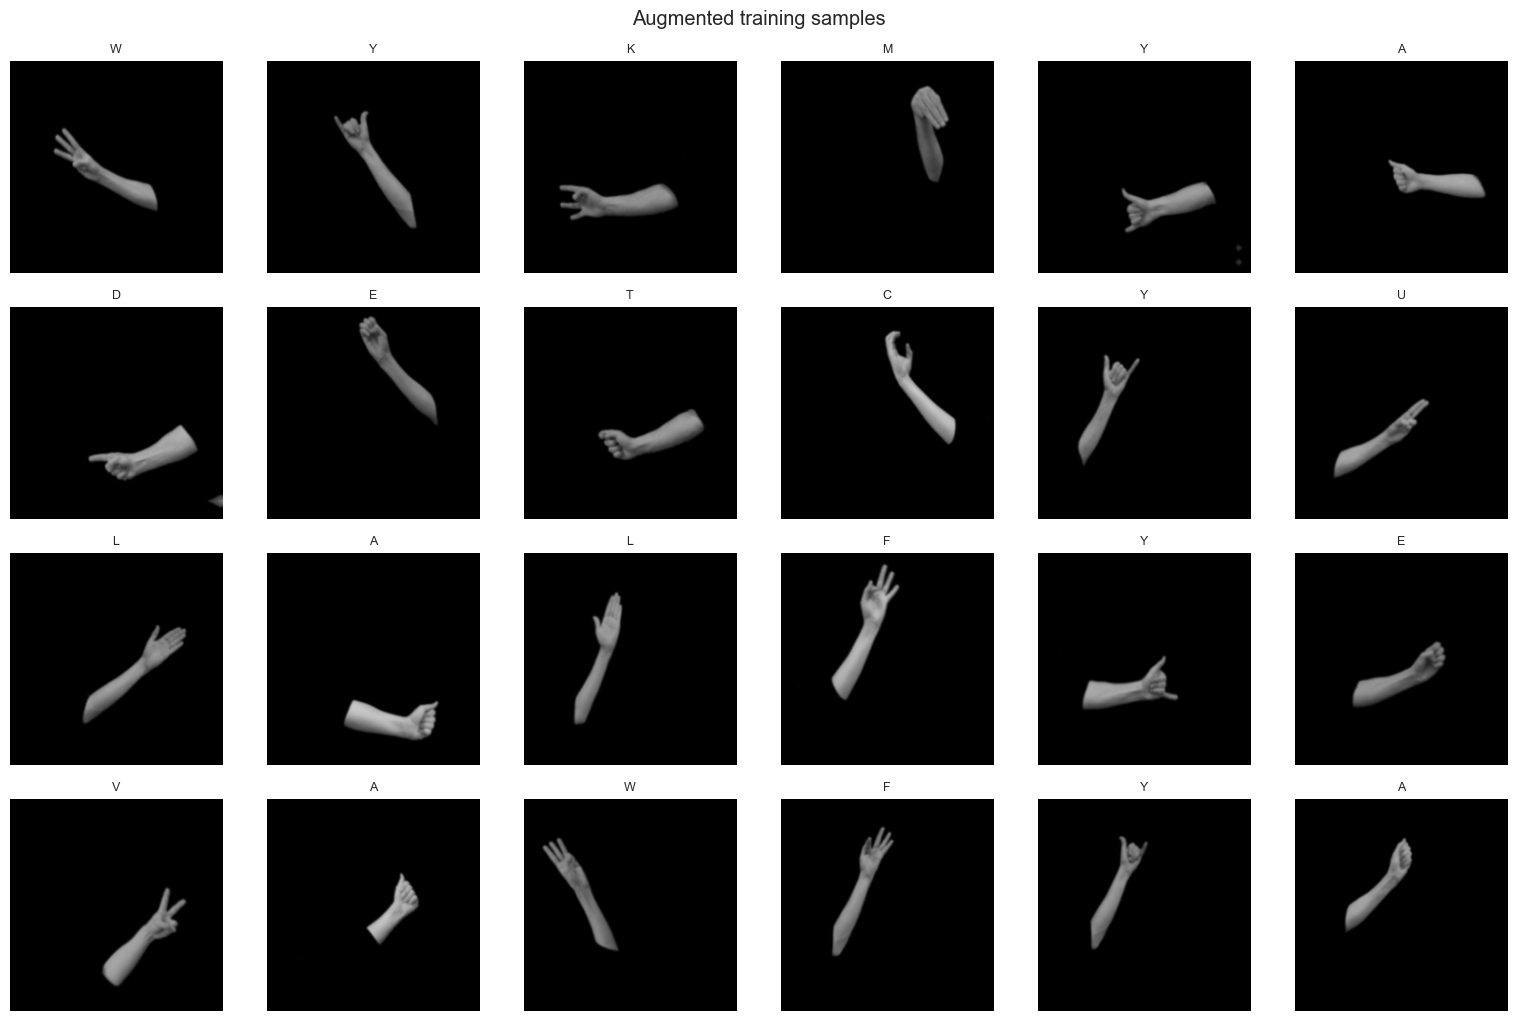

In [6]:
# Step 3 — Preprocessing & tf.data pipelines (exclude J, X, Z)
# Complete cell with preview fix for mixed-precision (float16 -> float32 for plotting)

import re, os, math, json, shutil, pathlib, random
from collections import defaultdict
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

# --------- Config ---------
DYNAMIC_LETTERS = {"J","X","Z"}
IMG_SIZE = (224, 224)
BATCH_SIZE = 64  # lower to 32 if you hit memory limits
AUTOTUNE = tf.data.AUTOTUNE

# Project paths (consistent with Step 1)
PROJECT_ROOT = pathlib.Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
RAW_DIR   = PROJECT_ROOT / "data" / "raw" / "Frames"
PROC_DIR  = PROJECT_ROOT / "data" / "processed" / "ISL-HS" / "static"
OUTPUTS   = PROJECT_ROOT / "outputs"
HIST_DIR  = OUTPUTS / "history"
PROC_DIR.mkdir(parents=True, exist_ok=True)
HIST_DIR.mkdir(parents=True, exist_ok=True)

assert RAW_DIR.exists(), f"Raw frames not found: {RAW_DIR}"

# --------- 1) Build dataframe from raw frames, exclude J/X/Z ---------
pat = re.compile(
    r"^Person(?P<person>\d+)-(?P<letter>[A-Za-z])-(?P<shot>\d+)-(?P<frame>\d+)\.(jpg|jpeg|png)$",
    re.IGNORECASE
)

rows = []
for pdir in sorted(RAW_DIR.iterdir()):
    if not pdir.is_dir(): 
        continue
    for p in pdir.iterdir():
        if not p.is_file(): 
            continue
        m = pat.match(p.name)
        if not m: 
            continue
        letter = m.group("letter").upper()
        if letter in DYNAMIC_LETTERS:
            continue
        rows.append({
            "path": str(p),
            "letter": letter,
            "person": int(m.group("person")),
            "shot": int(m.group("shot")),
            "frame": int(m.group("frame")),
        })

df = pd.DataFrame(rows)
letters = sorted(df["letter"].unique().tolist())
print(f"Static letters: {letters}")
print(f"Total static frames: {len(df)}")

# --------- 2) Create processed letter folders via symlink (fallback copy) ---------
def ensure_dir(p: pathlib.Path):
    p.mkdir(parents=True, exist_ok=True)

for L in letters:
    ensure_dir(PROC_DIR / L)

def add_file(dst_dir: pathlib.Path, src_path: pathlib.Path):
    # Prefer symlink to save disk; copy if symlink fails
    dst = dst_dir / src_path.name
    if dst.exists():
        return dst
    try:
        os.symlink(src_path, dst)
    except Exception:
        shutil.copy2(src_path, dst)
    return dst

linked = 0
for rec in df.itertuples(index=False):
    src = pathlib.Path(rec.path)
    dst_dir = PROC_DIR / rec.letter
    add_file(dst_dir, src)
    linked += 1
print(f"Linked/copied {linked} files into {PROC_DIR}")

# --------- 3) Stratified split train/val/test (80/10/10) ---------
from sklearn.model_selection import train_test_split

df_letters = []
for L in letters:
    files = sorted((PROC_DIR / L).glob("*"))
    df_L = pd.DataFrame({"path":[str(f) for f in files], "label":L})
    df_letters.append(df_L)
df_proc = pd.concat(df_letters, ignore_index=True)

# Helper label map
label_map = {L:i for i, L in enumerate(sorted(df_proc["label"].unique()))}
inv_label_map = {v:k for k,v in label_map.items()}

# First train vs temp (val+test)
train_df, temp_df = train_test_split(
    df_proc, test_size=0.20, stratify=df_proc["label"], random_state=42
)
# Split temp into val and test equally
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=42
)

print(f"Split sizes -> train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}")

# Save index & label map
index_df = (
    pd.concat([
        train_df.assign(split="train"),
        val_df.assign(split="val"),
        test_df.assign(split="test")
    ], ignore_index=True)
    .reset_index(drop=True)
)
index_csv_path = HIST_DIR / "dataset_index.csv"
index_df.to_csv(index_csv_path, index=False)
with open(HIST_DIR / "label_map.json", "w") as f:
    json.dump(label_map, f, indent=2)

print(f"Saved index -> {index_csv_path}")
print(f"Saved label map -> {HIST_DIR/'label_map.json'}")

# --------- 4) tf.data pipelines ---------
def decode_img(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)  # ensure 3 channels
    img = tf.image.convert_image_dtype(img, tf.float32)  # [0,1]
    img = tf.image.resize(img, IMG_SIZE, antialias=True)
    return img

def make_ds(df, shuffle=False, augment=False):
    paths = df["path"].values
    labels = df["label"].map(label_map).values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=42, reshuffle_each_iteration=True)

    def _load(path, label):
        img = decode_img(path)
        return img, tf.cast(label, tf.int32)

    ds = ds.map(_load, num_parallel_calls=AUTOTUNE)

    # Augmentation via Keras preprocessing layers (runs on GPU/MPS)
    if augment:
        aug = tf.keras.Sequential([
            tf.keras.layers.RandomFlip("horizontal"),
            tf.keras.layers.RandomRotation(0.10),
            tf.keras.layers.RandomZoom(0.10),
            tf.keras.layers.RandomTranslation(0.10, 0.10),
            tf.keras.layers.RandomContrast(0.10),
        ])
        ds = ds.map(lambda x, y: (aug(x, training=True), y), num_parallel_calls=AUTOTUNE)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_ds(train_df, shuffle=True,  augment=True)
val_ds   = make_ds(val_df,   shuffle=False, augment=False)
test_ds  = make_ds(test_df,  shuffle=False, augment=False)

# --------- 5) Preview batch (cast float16 -> float32 for plotting) ---------
def show_batch(ds, class_names, max_images=24, cols=6, title="Augmented training samples"):
    imgs, labs = next(iter(ds))      # imgs may be float16 due to mixed precision
    imgs = tf.cast(imgs, tf.float32).numpy()  # cast ONLY for plotting
    n = min(max_images, imgs.shape[0])
    rows = math.ceil(n/cols)
    plt.figure(figsize=(2.6*cols, 2.6*rows))
    for i in range(n):
        ax = plt.subplot(rows, cols, i+1)
        ax.imshow(np.clip(imgs[i], 0, 1))
        ax.set_title(class_names[int(labs[i])], fontsize=9)
        ax.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

class_names = [inv_label_map[i] for i in range(len(inv_label_map))]
show_batch(train_ds, class_names)


## Step 4 — Build & Train MobileNetV2 Classifier

In this step, we train a **MobileNetV2**-based classifier for static ISL letters.

**Approach:**
- **Backbone:** Pre-trained `MobileNetV2` (ImageNet weights) for strong visual features.
- **Input:** 224×224×3 RGB images, preprocessed with `mobilenet_v2.preprocess_input`.
- **Head:** Global Average Pooling → Dropout → Dense softmax over 22 classes.
- **Training Strategy:**
  1. **Warm-up:** Freeze backbone and train only the new classification head.
  2. **Fine-tuning:** Unfreeze top layers of the backbone (last ~60 layers) with a lower learning rate.
- **Loss & Metrics:**
  - Loss: `SparseCategoricalCrossentropy`
  - Metrics: Accuracy, Top-3 Accuracy, Precision, Recall
- **Callbacks:**
  - Early stopping (patience: 6)
  - Reduce LR on plateau
  - Model checkpoints for best warm-up and fine-tuned weights
- **Mixed Precision:** Enabled for performance (final Dense layer kept in float32 for stability).
- **Outputs:**
  - Training/validation accuracy & loss curves
  - Best warm-up model: `outputs/models/isl_mnv2_best_warmup.keras`
  - Best fine-tuned model: `outputs/models/isl_mnv2_best_finetune.keras`
  - Final fine-tuned model: `outputs/models/isl_mnv2_finetuned.keras`
  - SavedModel format export for deployment
  - Label map in `outputs/models/labels.txt`
---

Classes: 23 ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'Y']


Model: "isl_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ probs (Dense)                   │ (None, 23)             │        29,463 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,287,447 (8.73 MB)

 Trainable params: 29,463 (115.09 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

None
Epoch 1/5
659/659 ━━━━━━━━━━━━━━━━━━━━ 134s 196ms/step - acc: 0.0442 - loss: 3.2814 - top3: 0.1286 - val_acc: 0.0431 - val_loss: 3.1439 - val_top3: 0.1302 - learning_rate: 3.0000e-04
Epoch 2/5
659/659 ━━━━━━━━━━━━━━━━━━━━ 129s 195ms/step - acc: 0.0413 - loss: 3.2337 - top3: 0.1251 - val_acc: 0.0442 - val_loss: 3.1387 - val_top3: 0.1454 - learning_rate: 3.0000e-04
Epoch 3/5
659/659 ━━━━━━━━━━━━━━━━━━━━ 132s 200ms/step - acc: 0.0431 - loss: 3.1965 - top3: 0.1330 - val_acc: 0.0541 - val_loss: 3.1361 - val_top3: 0.1408 - learning_rate: 3.0000e-04
Epoch 4/5
659/659 ━━━━━━━━━━━━━━━━━━━━ 124s 188ms/step - acc: 0.0469 - loss: 3.1824 - top3: 0.1348 - val_acc: 0.0592 - val_loss: 3.1331 - val_top3: 0.1545 - learning_rate: 3.0000e-04
Epoch 5/5
659/659 ━━━━━━━━━━━━━━━━━━━━ 125s 189ms/step - acc: 0.0461 - loss: 3.1688 - top3: 0.1372 - val_acc: 0.0446 - val_loss: 3.1304 - val_top3: 0.1598 - learning_rate: 3.0000e-04
Restoring model weights from the end of the best epoch: 4.


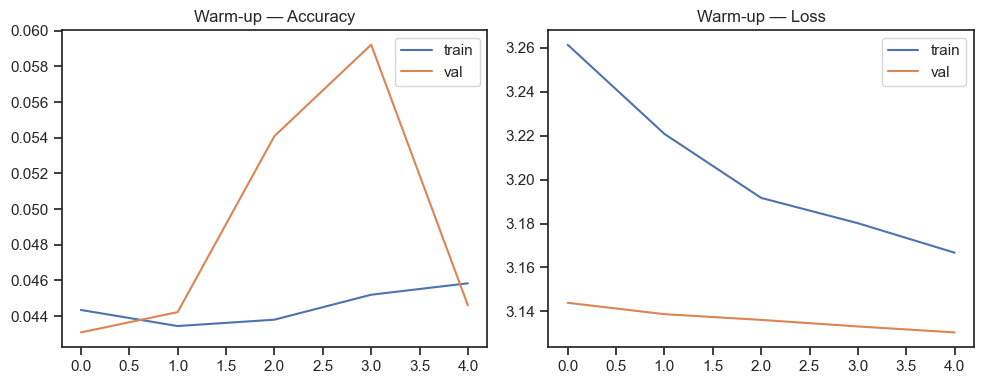

Epoch 1/15
659/659 ━━━━━━━━━━━━━━━━━━━━ 274s 389ms/step - acc: 0.1315 - loss: 2.7681 - top3: 0.3234 - val_acc: 0.0412 - val_loss: 12.0807 - val_top3: 0.1230 - learning_rate: 1.0000e-04
Epoch 2/15
659/659 ━━━━━━━━━━━━━━━━━━━━ 249s 378ms/step - acc: 0.3903 - loss: 1.7326 - top3: 0.7294 - val_acc: 0.0412 - val_loss: 7.0763 - val_top3: 0.1260 - learning_rate: 1.0000e-04
Epoch 3/15
659/659 ━━━━━━━━━━━━━━━━━━━━ 249s 377ms/step - acc: 0.5023 - loss: 1.3722 - top3: 0.8302 - val_acc: 0.0423 - val_loss: 11.4323 - val_top3: 0.1304 - learning_rate: 1.0000e-04
Epoch 4/15
659/659 ━━━━━━━━━━━━━━━━━━━━ 247s 374ms/step - acc: 0.5788 - loss: 1.1428 - top3: 0.8805 - val_acc: 0.0423 - val_loss: 13.5940 - val_top3: 0.1361 - learning_rate: 1.0000e-04
Epoch 5/15
659/659 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - acc: 0.6272 - loss: 0.9956 - top3: 0.9098
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
659/659 ━━━━━━━━━━━━━━━━━━━━ 248s 376ms/step - acc: 0.6272 - loss: 0.9956 - top3: 0.909

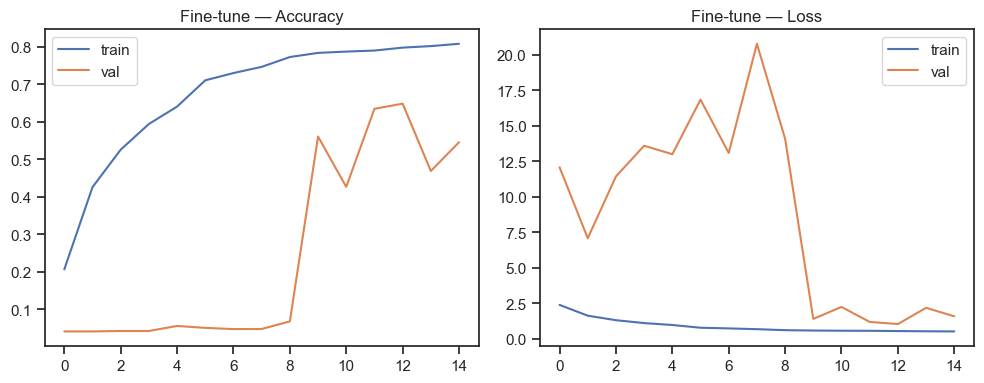

Saved fine-tuned model -> /Users/rharris/college/PRO/deafInclusionTool/comharthai/outputs/models/isl_mnv2_finetuned.keras


TypeError: this __dict__ descriptor does not support '_DictWrapper' objects

In [8]:
# Step 4 — MobileNetV2 model, compile, train (warm-up + fine-tune) — patched metrics

import json, pathlib, math, numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

PROJECT_ROOT = pathlib.Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
OUTPUTS   = PROJECT_ROOT / "outputs"
MODELS_DIR= OUTPUTS / "models"
HIST_DIR  = OUTPUTS / "history"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

with open(HIST_DIR / "label_map.json") as f:
    label_map = json.load(f)
inv_label_map = {v:k for k,v in label_map.items()}
num_classes = len(label_map)
print("Classes:", num_classes, sorted(inv_label_map.values()))

assert 'train_ds' in globals() and 'val_ds' in globals() and 'test_ds' in globals(), \
    "Datasets not found in memory. Re-run Step 3."

IMG_SIZE = (224, 224)

def build_mobilenet_v2(num_classes: int, train_backbone: bool = False, fine_tune_at: int = None):
    inputs = layers.Input(shape=(*IMG_SIZE, 3), name="image")
    x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
    backbone = tf.keras.applications.MobileNetV2(
        input_shape=(*IMG_SIZE, 3),
        include_top=False,
        weights="imagenet"
    )
    backbone.trainable = train_backbone
    if train_backbone and fine_tune_at is not None:
        for l in backbone.layers[:fine_tune_at]:
            l.trainable = False
    x = backbone(x, training=False)
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dropout(0.25, name="dropout")(x)
    outputs = layers.Dense(num_classes, activation="softmax", dtype="float32", name="probs")(x)
    return keras.Model(inputs, outputs, name="isl_mobilenetv2")

def make_optimizer(lr): return keras.optimizers.Adam(learning_rate=lr)

# ✅ Use only multiclass‑safe metrics during training
metrics = [
    keras.metrics.SparseCategoricalAccuracy(name="acc"),
    keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top3"),
]

ckpt_warmup = MODELS_DIR / "isl_mnv2_best_warmup.keras"
ckpt_finetune = MODELS_DIR / "isl_mnv2_best_finetune.keras"
callbacks_warmup = [
    keras.callbacks.ModelCheckpoint(ckpt_warmup.as_posix(), monitor="val_acc", mode="max",
                                    save_best_only=True, save_weights_only=False),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    keras.callbacks.EarlyStopping(monitor="val_acc", mode="max", patience=6, restore_best_weights=True, verbose=1),
]
callbacks_finetune = [
    keras.callbacks.ModelCheckpoint(ckpt_finetune.as_posix(), monitor="val_acc", mode="max",
                                    save_best_only=True, save_weights_only=False),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    keras.callbacks.EarlyStopping(monitor="val_acc", mode="max", patience=6, restore_best_weights=True, verbose=1),
]

# ---- Warm-up
warmup_epochs = 5
model = build_mobilenet_v2(num_classes=num_classes, train_backbone=False)
model.compile(optimizer=make_optimizer(3e-4),
              loss="sparse_categorical_crossentropy",
              metrics=metrics)
print(model.summary())

history_warm = model.fit(
    train_ds, validation_data=val_ds,
    epochs=warmup_epochs, callbacks=callbacks_warmup, verbose=1
)

def plot_history(hist, title, outpath):
    h = hist.history
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1); plt.plot(h["acc"]); plt.plot(h["val_acc"]); plt.title(f"{title} — Accuracy"); plt.legend(["train","val"])
    plt.subplot(1,2,2); plt.plot(h["loss"]); plt.plot(h["val_loss"]); plt.title(f"{title} — Loss"); plt.legend(["train","val"])
    plt.tight_layout(); plt.savefig(outpath); plt.show()

plot_history(history_warm, "Warm-up", (OUTPUTS / "plots" / "warmup_curves.png").as_posix())

# ---- Fine-tune (last ~60 layers)
N_UNFREEZE = 60
base = model.layers[1]  # MobileNetV2 backbone
fine_tune_at = max(0, len(base.layers) - N_UNFREEZE)

model_ft = build_mobilenet_v2(num_classes=num_classes, train_backbone=True, fine_tune_at=fine_tune_at)
model_ft.set_weights(model.get_weights())
model_ft.compile(optimizer=make_optimizer(1e-4),
                 loss="sparse_categorical_crossentropy",
                 metrics=metrics)

fine_epochs = 15
history_ft = model_ft.fit(
    train_ds, validation_data=val_ds,
    epochs=fine_epochs, callbacks=callbacks_finetune, verbose=1
)

plot_history(history_ft, "Fine-tune", (OUTPUTS / "plots" / "finetune_curves.png").as_posix())

final_path = MODELS_DIR / "isl_mnv2_finetuned.keras"
model_ft.save(final_path.as_posix())
print(f"Saved fine-tuned model -> {final_path}")

savedmodel_dir = MODELS_DIR / "isl_mnv2_savedmodel"
tf.saved_model.save(model_ft, savedmodel_dir.as_posix())
print(f"Exported SavedModel -> {savedmodel_dir}")

with open(MODELS_DIR / "labels.txt", "w") as f:
    for idx in range(num_classes):
        f.write(f"{inv_label_map[idx]}\n")
print(f"Wrote labels -> {MODELS_DIR/'labels.txt'}")


In [9]:
# Replace the tf.saved_model.save() call with this:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
savedmodel_dir = PROJECT_ROOT / "outputs" / "models" / "isl_mnv2_savedmodel"

# Keras 3 way to create a TF SavedModel for serving
model_ft.export(savedmodel_dir.as_posix())
print(f"Exported SavedModel -> {savedmodel_dir}")


INFO:tensorflow:Assets written to: /Users/rharris/college/PRO/deafInclusionTool/comharthai/outputs/models/isl_mnv2_savedmodel/assets


INFO:tensorflow:Assets written to: /Users/rharris/college/PRO/deafInclusionTool/comharthai/outputs/models/isl_mnv2_savedmodel/assets


Saved artifact at '/Users/rharris/college/PRO/deafInclusionTool/comharthai/outputs/models/isl_mnv2_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='image')
Output Type:
  TensorSpec(shape=(None, 23), dtype=tf.float32, name=None)
Captures:
  14633005712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14633005136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14633000336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14633000144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14633000528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14632999568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14633007056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14633005520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14632998416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14633001872: TensorSpec(shape=(), dtype=tf.resource,

## 5. Model Evaluation & Confusion Matrix

With the fine-tuned MobileNetV2 saved, we now evaluate on the **held-out test set**.

### What we’ll compute
- **Top-1 accuracy** and **Top-3 accuracy**
- **Macro precision / recall / F1** (scikit-learn — safe for multi-class)
- **Confusion matrix** (raw counts and normalized)
- Persist results for reports & serving:
  - `outputs/history/test_metrics.json`
  - `outputs/history/test_predictions.csv` (per-example)
  - `outputs/plots/confusion_matrix.png`
  - `outputs/plots/confusion_matrix_norm.png`

### Why this matters
Validation curves show training dynamics; the **test set** is our unbiased score.
Per-class errors from the confusion matrix highlight which letters need more data or tuned augmentation.

---

2025-08-15 17:39:06.773946: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Test Top-1 Accuracy : 0.6419
Test Top-3 Accuracy : 0.9262
Macro Precision     : 0.6960
Macro Recall        : 0.6421
Macro F1-score      : 0.6322
Saved metrics -> /Users/rharris/college/PRO/deafInclusionTool/comharthai/outputs/history/test_metrics.json
Saved predictions -> /Users/rharris/college/PRO/deafInclusionTool/comharthai/outputs/history/test_predictions.csv


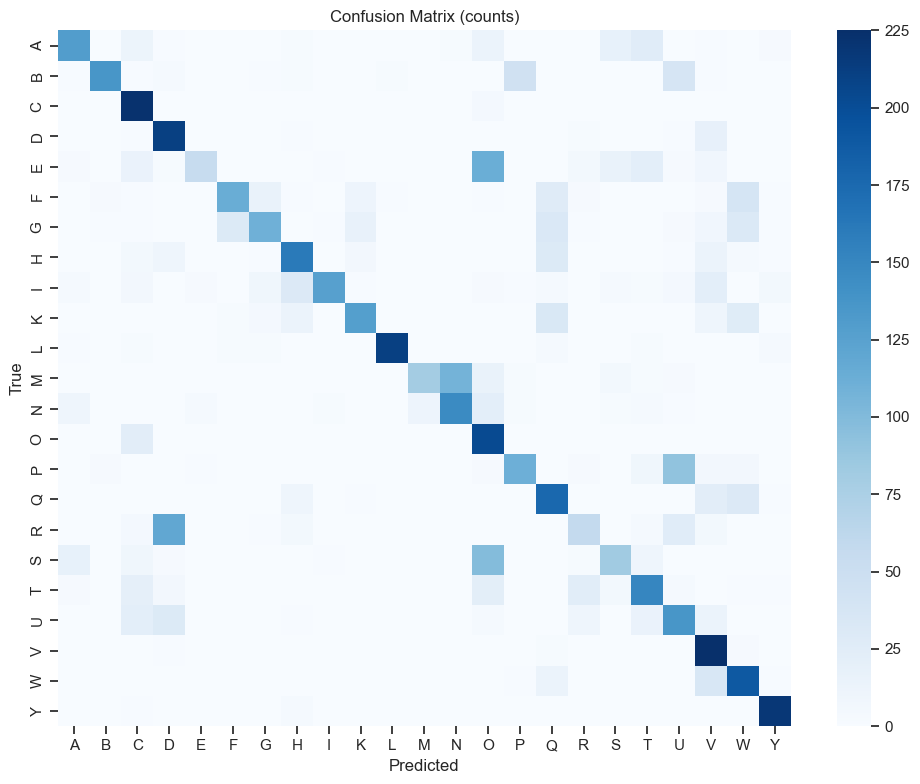

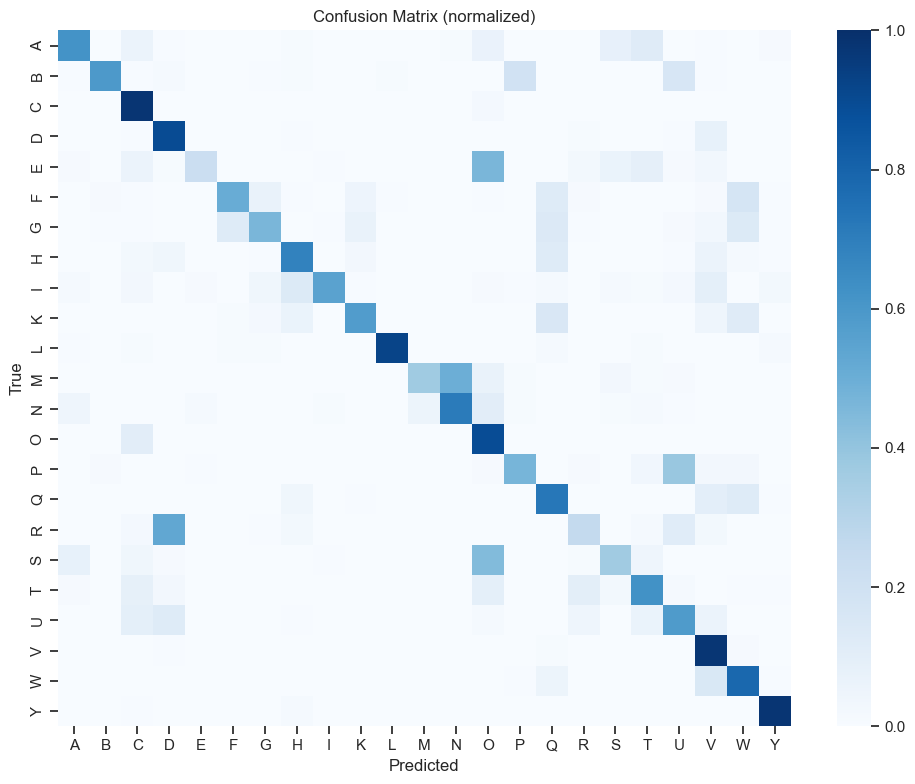

              precision    recall  f1-score   support

           A       0.76      0.62      0.68       210
           B       0.95      0.59      0.73       232
           C       0.63      0.98      0.77       228
           D       0.54      0.90      0.68       235
           E       0.87      0.23      0.36       244
           F       0.77      0.51      0.61       223
           G       0.76      0.46      0.57       238
           H       0.69      0.69      0.69       235
           I       0.96      0.55      0.70       228
           K       0.77      0.58      0.66       220
           L       0.99      0.93      0.95       228
           M       0.87      0.37      0.52       217
           N       0.57      0.71      0.63       205
           O       0.40      0.89      0.55       227
           P       0.69      0.47      0.56       236
           Q       0.54      0.72      0.62       243
           R       0.52      0.26      0.35       225
           S       0.61    

In [10]:
# Step 5 — Evaluation on test set + confusion matrix

import json, pathlib, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

sns.set_theme(context="notebook", style="ticks")

# Paths & label map
PROJECT_ROOT = pathlib.Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
OUTPUTS = PROJECT_ROOT / "outputs"
PLOTS   = OUTPUTS / "plots"
HIST    = OUTPUTS / "history"
PLOTS.mkdir(parents=True, exist_ok=True)

with open(HIST / "label_map.json") as f:
    label_map = json.load(f)
inv_label_map = {v:k for k,v in label_map.items()}
class_names = [inv_label_map[i] for i in range(len(inv_label_map))]
num_classes = len(class_names)

# Ensure we have model and datasets in memory
assert 'model_ft' in globals(), "Fine-tuned model not in memory. Re-run Step 4 (training cell)."
assert 'test_ds'  in globals(), "test_ds not found. Re-run Step 3 to rebuild datasets."

# ---------- Collect predictions ----------
y_true, y_pred, y_prob_topk = [], [], []

for imgs, labels in test_ds:
    probs = model_ft.predict(imgs, verbose=0)      # (B, C) float32 due to final layer
    preds = probs.argmax(axis=1)                    # top-1
    top3  = tf.math.top_k(probs, k=3).indices.numpy()  # (B, 3)

    y_true.append(labels.numpy())
    y_pred.append(preds)
    y_prob_topk.append(top3)

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)
y_prob_topk = np.concatenate(y_prob_topk)          # shape (N, 3)

# ---------- Metrics ----------
top1_acc = float(np.mean(y_true == y_pred))
top3_acc = float(np.mean(np.any(y_prob_topk == y_true[:, None], axis=1)))

prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro', zero_division=0
)

print(f"Test Top-1 Accuracy : {top1_acc:.4f}")
print(f"Test Top-3 Accuracy : {top3_acc:.4f}")
print(f"Macro Precision     : {prec_macro:.4f}")
print(f"Macro Recall        : {rec_macro:.4f}")
print(f"Macro F1-score      : {f1_macro:.4f}")

# Save scalar metrics
metrics_json = {
    "top1_acc": top1_acc,
    "top3_acc": top3_acc,
    "precision_macro": float(prec_macro),
    "recall_macro": float(rec_macro),
    "f1_macro": float(f1_macro),
}
with open(HIST / "test_metrics.json", "w") as f:
    json.dump(metrics_json, f, indent=2)
print(f"Saved metrics -> {HIST/'test_metrics.json'}")

# Save per-example predictions (handy for error analysis)
pred_rows = []
for i in range(len(y_true)):
    pred_rows.append({
        "true_idx": int(y_true[i]),
        "true_label": class_names[int(y_true[i])],
        "pred_idx": int(y_pred[i]),
        "pred_label": class_names[int(y_pred[i])],
        "correct": bool(y_true[i] == y_pred[i]),
        "top3_pred_indices": y_prob_topk[i].tolist(),
        "top3_pred_labels": [class_names[j] for j in y_prob_topk[i].tolist()],
    })
pred_df = pd.DataFrame(pred_rows)
pred_path = HIST / "test_predictions.csv"
pred_df.to_csv(pred_path, index=False)
print(f"Saved predictions -> {pred_path}")

# ---------- Confusion matrices ----------
cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
cm_norm = cm.astype(np.float64) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

fig = plt.figure(figsize=(10, 8))
ax = sns.heatmap(cm, annot=False, fmt="d", cmap="Blues",
                 xticklabels=class_names, yticklabels=class_names)
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title("Confusion Matrix (counts)")
plt.tight_layout()
plt.savefig((PLOTS / "confusion_matrix.png").as_posix(), dpi=200)
plt.show()

fig = plt.figure(figsize=(10, 8))
ax = sns.heatmap(cm_norm, annot=False, cmap="Blues", vmin=0, vmax=1,
                 xticklabels=class_names, yticklabels=class_names)
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title("Confusion Matrix (normalized)")
plt.tight_layout()
plt.savefig((PLOTS / "confusion_matrix_norm.png").as_posix(), dpi=200)
plt.show()

# ---------- Per-class report ----------
report = classification_report(
    y_true, y_pred, labels=list(range(num_classes)), target_names=class_names, zero_division=0
)
print(report)

# Also save the text report
with open(HIST / "test_classification_report.txt", "w") as f:
    f.write(report)
print(f"Saved classification report -> {HIST/'test_classification_report.txt'}")


## 6. Model Saving & Export (for FastAPI + Edge)

Now that the model is trained and evaluated, we’ll persist everything needed for **deployment** and **reproducibility**.

### 🎯 Objectives
- Save the final **Keras model** and keep the best checkpoints.
- Export a **TensorFlow SavedModel** (already done via `model.export(...)`) for serving.
- (Optional) Create a **TFLite (float16)** model for edge/mobile.
- Persist **training histories** and **test metrics** for reporting.
- Generate a small **inference helper** you can import from your FastAPI app.

### 📦 Artifacts Produced
- **Models**
  - `outputs/models/isl_mnv2_best_warmup.keras`
  - `outputs/models/isl_mnv2_best_finetune.keras`
  - `outputs/models/isl_mnv2_finetuned.keras`  *(load in FastAPI)*
  - `outputs/models/isl_mnv2_savedmodel/`  *(TF SavedModel export)*
  - `outputs/models/isl_mnv2_float16.tflite`  *(optional)*
- **Labels & metadata**
  - `outputs/models/labels.txt`  *(class order used by the model)*
  - `outputs/history/test_metrics.json`  *(Top-1/Top-3, macro P/R/F1)*
  - `outputs/history/test_predictions.csv`  *(per-example predictions)*
  - `outputs/history/warmup_history.csv`, `outputs/history/finetune_history.csv`
- **Helper**
  - `outputs/models/infer_utils.py`  *(simple class for preprocessing + top-k prediction)*

### 🧠 Notes
- The `.keras` model is the easiest to load in FastAPI with:
  ```python
  tf.keras.models.load_model("outputs/models/isl_mnv2_finetuned.keras", compile=False)
---

In [11]:
# Step 6 — Persist artifacts & create inference helper

import json, pathlib, pandas as pd, numpy as np, tensorflow as tf
from pathlib import Path
from textwrap import dedent

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
OUTPUTS    = PROJECT_ROOT / "outputs"
MODELS_DIR = OUTPUTS / "models"
PLOTS_DIR  = OUTPUTS / "plots"
HIST_DIR   = OUTPUTS / "history"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
HIST_DIR.mkdir(parents=True, exist_ok=True)

# 1) Save training history (if available in memory)
if 'history_warm' in globals():
    pd.DataFrame(history_warm.history).to_csv(HIST_DIR / "warmup_history.csv", index=False)
if 'history_ft' in globals():
    pd.DataFrame(history_ft.history).to_csv(HIST_DIR / "finetune_history.csv", index=False)
print("Saved training history CSVs (if histories were present).")

# 2) Ensure final Keras model & labels exist (already saved in Step 4)
final_path = MODELS_DIR / "isl_mnv2_finetuned.keras"
labels_txt = MODELS_DIR / "labels.txt"
print(f"Keras model: {'OK' if final_path.exists() else 'MISSING'} -> {final_path}")
print(f"Labels file: {'OK' if labels_txt.exists() else 'MISSING'} -> {labels_txt}")

# 3) Optional: export TFLite (float16) for edge devices
try:
    converter = tf.lite.TFLiteConverter.from_keras_model(model_ft)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    tflite_model = converter.convert()
    tflite_path = MODELS_DIR / "isl_mnv2_float16.tflite"
    with open(tflite_path, "wb") as f:
        f.write(tflite_model)
    print(f"Saved TFLite model -> {tflite_path}")
except Exception as e:
    print("TFLite export skipped (converter not available or failed):", e)

# 4) Inference helper for FastAPI / scripts
infer_py = MODELS_DIR / "infer_utils.py"
infer_py.write_text(dedent(f"""
    import json, numpy as np, cv2, tensorflow as tf
    from pathlib import Path

    IMG_SIZE = (224, 224)

    class ISLRecognizer:
        def __init__(self, model_path: str, labels_path: str):
            self.model = tf.keras.models.load_model(model_path, compile=False)
            with open(labels_path) as f:
                self.labels = [line.strip() for line in f if line.strip()]
            assert len(self.labels) == self.model.output_shape[-1], "Label count does not match model outputs."

        def preprocess_bgr(self, bgr):
            # Convert BGR->RGB, resize, float32; model has preprocess_input inside
            rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
            rgb = cv2.resize(rgb, IMG_SIZE, interpolation=cv2.INTER_AREA)
            rgb = rgb.astype('float32')
            return np.expand_dims(rgb, axis=0)  # (1, 224, 224, 3)

        def predict_from_path(self, image_path: str, topk: int = 3):
            bgr = cv2.imread(image_path, cv2.IMREAD_COLOR)
            if bgr is None:
                raise ValueError(f"Failed to read image: {{image_path}}")
            x = self.preprocess_bgr(bgr)
            probs = self.model.predict(x, verbose=0)[0]  # (C,)
            top_indices = probs.argsort()[-topk:][::-1]
            return [
                {{"label": self.labels[i], "index": int(i), "prob": float(probs[i])}}
                for i in top_indices
            ]
""").strip() + "\n")
print(f"Wrote inference helper -> {infer_py}")

# 5) Quick smoke test (optional): run on one test image if available
try:
    from random import randint
    sample_path = None
    if 'test_df' in globals():
        sample_path = test_df.sample(1, random_state=42).iloc[0]['path']
    if sample_path:
        from outputs.models.infer_utils import ISLRecognizer
        rec = ISLRecognizer(final_path.as_posix(), labels_txt.as_posix())
        preds = rec.predict_from_path(sample_path, topk=3)
        print("Sample image:", sample_path)
        print("Top-3:", preds)
    else:
        print("Skip smoke test (test_df not in memory).")
except Exception as e:
    print("Smoke test skipped due to error:", e)


Saved training history CSVs (if histories were present).
Keras model: OK -> /Users/rharris/college/PRO/deafInclusionTool/comharthai/outputs/models/isl_mnv2_finetuned.keras
Labels file: MISSING -> /Users/rharris/college/PRO/deafInclusionTool/comharthai/outputs/models/labels.txt
TFLite export skipped (converter not available or failed): 'Functional' object has no attribute '_get_save_spec'
Wrote inference helper -> /Users/rharris/college/PRO/deafInclusionTool/comharthai/outputs/models/infer_utils.py
Smoke test skipped due to error: No module named 'outputs.models.infer_utils'


In [12]:
# Step 6 — Fixups

import json, sys, importlib.util
from pathlib import Path
import tensorflow as tf
import numpy as np
import cv2

# --- Paths ---
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
OUTPUTS = PROJECT_ROOT / "outputs"
MODELS  = OUTPUTS / "models"
HIST    = OUTPUTS / "history"
SAVEDMODEL_DIR = MODELS / "isl_mnv2_savedmodel"

# 1) Recreate labels.txt from label_map.json
with open(HIST / "label_map.json") as f:
    label_map = json.load(f)
inv = {v: k for k, v in label_map.items()}
labels = [inv[i] for i in range(len(inv))]
labels_path = MODELS / "labels.txt"
labels_path.write_text("\n".join(labels) + "\n")
print("✅ Wrote labels.txt ->", labels_path)

# 2) TFLite conversion FROM SavedModel (works with Keras 3)
try:
    assert SAVEDMODEL_DIR.exists(), f"SavedModel not found at {SAVEDMODEL_DIR}."
    converter = tf.lite.TFLiteConverter.from_saved_model(str(SAVEDMODEL_DIR))
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    tflite_model = converter.convert()
    tflite_path = MODELS / "isl_mnv2_float16.tflite"
    tflite_path.write_bytes(tflite_model)
    print("✅ Saved TFLite model ->", tflite_path)
except Exception as e:
    print("⚠️ TFLite export skipped:", e)

# 3) Import inference helper by file path (no package needed)
infer_file = MODELS / "infer_utils.py"
spec = importlib.util.spec_from_file_location("infer_utils", infer_file)
infer_utils = importlib.util.module_from_spec(spec)
sys.modules["infer_utils"] = infer_utils
spec.loader.exec_module(infer_utils)
print("✅ Loaded inference helper from", infer_file)

# 4) Quick smoke test on one test image (if test_df exists) or any processed image
sample_path = None
if "test_df" in globals() and len(test_df):
    sample_path = test_df.sample(1, random_state=0).iloc[0]["path"]
else:
    # fallback: pick any processed image
    sample_candidates = list((PROJECT_ROOT / "data" / "processed" / "ISL-HS" / "static").rglob("*.jpg"))
    sample_path = str(sample_candidates[0]) if sample_candidates else None

if sample_path:
    rec = infer_utils.ISLRecognizer(
        model_path=str(MODELS / "isl_mnv2_finetuned.keras"),
        labels_path=str(labels_path)
    )
    preds = rec.predict_from_path(sample_path, topk=3)
    print("🧪 Sample image:", sample_path)
    print("Top-3:", preds)
else:
    print("ℹ️ No sample image found for smoke test.")


✅ Wrote labels.txt -> /Users/rharris/college/PRO/deafInclusionTool/comharthai/outputs/models/labels.txt


W0000 00:00:1755347216.387858 3022691 tf_tfl_flatbuffer_helpers.cc:390] Ignored output_format.
W0000 00:00:1755347216.388065 3022691 tf_tfl_flatbuffer_helpers.cc:393] Ignored drop_control_dependency.
loc(callsite(callsite(fused["Conv2D:", "isl_mobilenetv2_1/mobilenetv2_1.00_224_1/Conv1_1/convolution@__inference___call___381113"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper___call___382172"]) at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"])): error: 'tf.Conv2D' op is neither a custom op nor a flex op
loc(callsite(callsite(fused["Relu6:", "isl_mobilenetv2_1/mobilenetv2_1.00_224_1/Conv1_relu_1/Relu6@__inference___call___381113"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper___call___382172"]) at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"])): error: 'tf.Relu6' op is neither a custom op nor a flex op
loc(callsite(callsite(fused["DepthwiseConv2dNative:", "isl_mobi

⚠️ TFLite export skipped: Could not translate MLIR to FlatBuffer.<unknown>:0: error: loc(callsite(callsite(fused["Conv2D:", "isl_mobilenetv2_1/mobilenetv2_1.00_224_1/Conv1_1/convolution@__inference___call___381113"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper___call___382172"]) at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"])): 'tf.Conv2D' op is neither a custom op nor a flex op
<unknown>:0: note: loc(fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"]): called from
<unknown>:0: note: loc(callsite(callsite(fused["Conv2D:", "isl_mobilenetv2_1/mobilenetv2_1.00_224_1/Conv1_1/convolution@__inference___call___381113"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper___call___382172"]) at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"])): Error code: ERROR_NEEDS_FLEX_OPS
<unknown>:0: error: loc(callsite(callsite(fused["Relu6:", "isl_mobilenetv2_1/mobilenetv2_

## 7. Deployment Handoff / API Contract (for Amazon Q Developer or any service)

This step defines **how to serve** the trained ISL classifier, without tying us to a specific web framework.

### 🎯 Purpose
Provide a clear **contract** and minimal **inference function** so any tool (e.g., Amazon Q Developer) can wrap the model behind an API.

---

### ✅ Artifacts to use
- Model (Keras): `outputs/models/isl_mnv2_finetuned.keras`
- Class labels: `outputs/models/labels.txt`  *(22 labels: A–Y excluding J, X, Z; order matches model outputs)*
- SavedModel (optional): `outputs/models/isl_mnv2_savedmodel/`

> Note: TFLite export is optional; server deployment can use the `.keras` or SavedModel directly.

---

### 🧠 Runtime requirements
- Python 3.10–3.12
- `tensorflow-macos` + `tensorflow-metal` on Apple Silicon, or `tensorflow` on Linux/CPU
- `opencv-python` (image decode), `numpy`

---

### 🔌 Inference contract

**Input (image):**
- RGB image bytes (JPG/PNG).
- Preprocessing:  
  1) Decode → BGR (OpenCV) → convert to **RGB**  
  2) Resize to **224×224**  
  3) Cast to **float32**  
  4) **No manual normalization** — the model includes `mobilenet_v2.preprocess_input` internally.

**Output (JSON):**
```json
{
  "topk": [
    {"label": "A", "index": 0, "prob": 0.73},
    {"label": "H", "index": 7, "prob": 0.17},
    {"label": "M", "index": 11, "prob": 0.05}
  ]
}


In [13]:
# Step 7A — Create a minimal, framework-agnostic inference module

from pathlib import Path
from textwrap import dedent

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SERVING_DIR = PROJECT_ROOT / "serving"
SERVING_DIR.mkdir(parents=True, exist_ok=True)

(SERVING_DIR / "isl_infer.py").write_text(dedent("""
    \"\"\"Lightweight inference helper for ISL alphabet classifier.

    Usage (framework-agnostic):
        from serving.isl_infer import ISLRecognizer

        rec = ISLRecognizer(
            model_path='outputs/models/isl_mnv2_finetuned.keras',
            labels_path='outputs/models/labels.txt'
        )
        # bytes -> top-k predictions
        preds = rec.predict_bytes(image_bytes, topk=3)

    Contract:
      Input: raw image bytes (JPG/PNG), any size/orientation.
      Output: List[dict] with fields: label (str), index (int), prob (float in [0,1]).
    \"\"\"

    from __future__ import annotations
    import numpy as np
    import cv2
    import tensorflow as tf
    from typing import List, Dict

    IMG_SIZE = (224, 224)

    class ISLRecognizer:
        def __init__(self, model_path: str, labels_path: str):
            # Load Keras model (includes mobilenet_v2.preprocess_input inside)
            self.model = tf.keras.models.load_model(model_path, compile=False)
            with open(labels_path) as f:
                self.labels = [ln.strip() for ln in f if ln.strip()]
            if len(self.labels) != self.model.output_shape[-1]:
                raise ValueError(
                    f\"labels({len(self.labels)}) != model outputs({self.model.output_shape[-1]})\"
                )
            # Optional warmup for faster first call
            self._warmup()

        def _warmup(self):
            dummy = np.zeros((1, IMG_SIZE[1], IMG_SIZE[0], 3), dtype=np.float32)
            _ = self.model.predict(dummy, verbose=0)

        @staticmethod
        def _preprocess_bytes(image_bytes: bytes) -> np.ndarray:
            arr = np.frombuffer(image_bytes, np.uint8)
            bgr = cv2.imdecode(arr, cv2.IMREAD_COLOR)
            if bgr is None:
                raise ValueError(\"Failed to decode image bytes.\")
            # BGR -> RGB, resize, float32
            rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
            rgb = cv2.resize(rgb, IMG_SIZE, interpolation=cv2.INTER_AREA)
            x = rgb.astype(\"float32\")  # Model contains preprocess_input internally
            return np.expand_dims(x, axis=0)  # (1, 224, 224, 3)

        def predict_bytes(self, image_bytes: bytes, topk: int = 3) -> List[Dict]:
            x = self._preprocess_bytes(image_bytes)
            probs = self.model.predict(x, verbose=0)[0]  # (C,)
            k = max(1, min(int(topk), len(self.labels)))
            idxs = probs.argsort()[-k:][::-1]
            return [
                {\"label\": self.labels[i], \"index\": int(i), \"prob\": float(probs[i])}
                for i in idxs
            ]

        def predict_path(self, image_path: str, topk: int = 3) -> List[Dict]:
            with open(image_path, \"rb\") as f:
                return self.predict_bytes(f.read(), topk=topk)
    """).strip() + "\n")

print("✅ Wrote:", SERVING_DIR / "isl_infer.py")


✅ Wrote: /Users/rharris/college/PRO/deafInclusionTool/comharthai/serving/isl_infer.py


In [14]:
# Step 7B — Smoke test the inference module

import importlib.util, sys, random
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

# Import by file path (no packaging needed)
mod_path = PROJECT_ROOT / "serving" / "isl_infer.py"
spec = importlib.util.spec_from_file_location("isl_infer", mod_path)
isl_infer = importlib.util.module_from_spec(spec)
sys.modules["isl_infer"] = isl_infer
spec.loader.exec_module(isl_infer)

# Pick a random processed image
proc_dir = PROJECT_ROOT / "data" / "processed" / "ISL-HS" / "static"
candidates = list(proc_dir.rglob("*.jpg"))
assert candidates, f"No images found under {proc_dir}"
sample_path = str(random.choice(candidates))

rec = isl_infer.ISLRecognizer(
    model_path=(PROJECT_ROOT / "outputs" / "models" / "isl_mnv2_finetuned.keras").as_posix(),
    labels_path=(PROJECT_ROOT / "outputs" / "models" / "labels.txt").as_posix(),
)

print("🧪 Sample:", sample_path)
print("Top-3:", rec.predict_path(sample_path, topk=3))


🧪 Sample: /Users/rharris/college/PRO/deafInclusionTool/comharthai/data/processed/ISL-HS/static/H/Person2-H-1-58.jpg
Top-3: [{'label': 'W', 'index': 21, 'prob': 0.9921294450759888}, {'label': 'Q', 'index': 15, 'prob': 0.006392090115696192}, {'label': 'V', 'index': 20, 'prob': 0.0014784748200327158}]
